In [1]:
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.datasets import make_regression

In [2]:
X, y = make_regression(n_samples=100 ,n_features=1, n_informative=1, n_targets=1, noise=20, random_state=13)

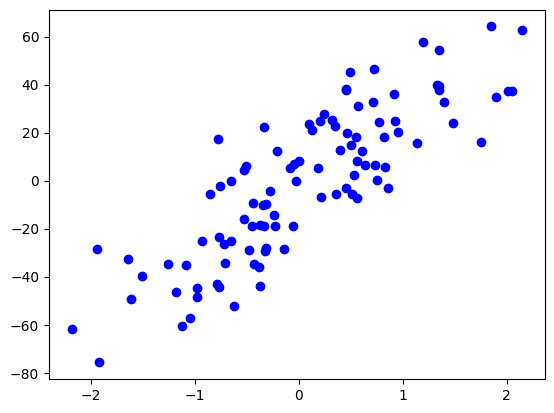

In [3]:
plt.scatter(X, y, color='blue')

In [4]:
lr = LinearRegression()

lr.fit(X, y)
print(lr.coef_)
print(lr.intercept_)

[27.82809103]
-2.29474455867698


In [5]:
rg = Ridge(alpha=10)

rg.fit(X, y)
print(rg.coef_)
print(rg.intercept_)

[24.9546267]
-2.126913003523573


In [6]:
rg1 = Ridge(alpha=100)

rg1.fit(X, y)
print(rg1.coef_)
print(rg1.intercept_)

[12.93442104]
-1.4248441496033308


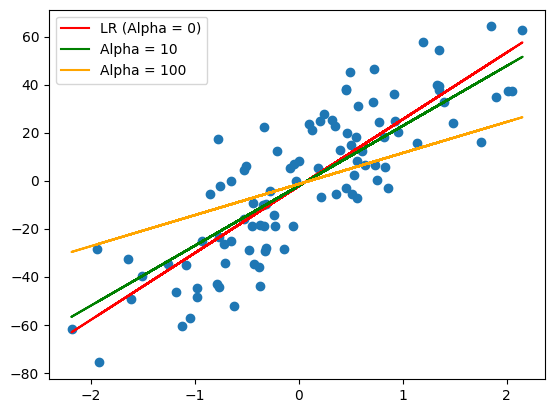

In [7]:
plt.scatter(X, y)
plt.plot(X, lr.predict(X), color='red', label='LR (Alpha = 0)')
plt.plot(X, rg.predict(X), color='green', label='Alpha = 10')
plt.plot(X, rg1.predict(X), color='orange', label='Alpha = 100')
plt.legend()

### Making our own class:

In [8]:
class My_Ridge:
	def __init__(self, alpha=0.1):
		self.alpha = alpha
		self.b = None
		self.m = None
		
	def fit(self, X_train, y_train):
		num = 0
		den = 0

		for i in range(X_train.shape[0]):
			num = num + (y_train[i] - y_train.mean()) * (X_train[i] - X_train.mean())
			den = den + (X_train[i] - X_train.mean()) * (X_train[i] - X_train.mean())

		self.m = num / (den  + self.alpha)
		self.b = y_train.mean() - (self.m * X_train.mean())

		print(self.m, self.b)

	def predict(self, X_test):
		return (self.m * X_test) + self.b

In [9]:
reg = My_Ridge(alpha=10)

reg.fit(X, y)

[24.9546267] [-2.126913]


In [10]:
reg = My_Ridge(alpha=100)

reg.fit(X, y)

[12.93442104] [-1.42484415]
